Your README must contain:
• Original research question from Phase 1
• Your target variable and all features used across Phase 3 and Phase 4
• Final dataset shape used for modeling (rows x columns)
• One sentence describing what changed between Phase 3 and Phase 4 and why

You must write 3 to 5 sentences answering the following in your notebook:
• What was the evaluation setup in Phase 3, and why is it problematic?
• What does a train/test split fix, in your own words?
• Do you expect your Phase 3 RMSE to go up or down when evaluated on held-out data,
and why?


Part 1:

The evaluation setup for phase 3 was training on a full dataset which is problematic because the model memorizes the dataset rather than learn and predicting. Test and training datasets allow the model to predict behavior given some information and then applies the patterns it recognized to a dataset it does not know. We can expect our phase 3 RMSE to increase because rather than memorizing patterns and noise in the data it was trained on, it is tested with data it has not seen before which will create more mistakes.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import plotly.graph_objects as go

df = pd.read_csv('phase3.csv')

In [4]:
df

,Date,Close_Splits,Volume_Splits,Open_Splits,High_Splits,Low_Splits,Open_NoSplits,High_NoSplits,Low_NoSplits,Close_NoSplits,...,Price_Range,Price_Change,Profit,pred_constant,error,squared_error,pred_linear,error_linear,squared_error_linear,Prev_Close
0,2020-02-27,$273.52,80151380,$281.1,$286,$272.96,67.984578,69.169651,66.015900,66.151337,...,3.153751,-1.833242,False,26.17548,39.975856,1598.069090,67.353379,-1.202042,1.444906,66.112656
1,2020-02-26,$292.65,49678430,$286.53,$297.88,$286.5,69.297844,72.042865,69.290589,70.777977,...,2.752277,1.480133,True,26.17548,44.602497,1989.382708,68.220993,2.556984,6.538168,66.151337
2,2020-02-25,$288.08,57668360,$300.95,$302.53,$286.13,72.785347,73.167470,69.201100,69.672707,...,3.966371,-3.112641,False,26.17548,43.497226,1892.008693,72.109833,-2.437127,5.939587,70.777977
3,2020-02-24,$298.18,55548830,$297.26,$304.18,$289.23,71.892933,73.566545,69.950862,72.115433,...,3.615683,0.222500,True,26.17548,45.939952,2110.479227,71.142269,0.973164,0.947048,69.672707
4,2020-02-21,$313.05,32426420,$318.62,$320.45,$310.5,77.058879,77.501472,75.095042,75.711761,...,2.406430,-1.347117,False,26.17548,49.536281,2453.843149,75.357597,0.354165,0.125433,72.115433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2512,2010-03-05,$31.2786,224647427,$30.7057,$31.3857,$30.6614,6.446276,6.589033,6.436978,6.566540,...,0.152055,0.120264,True,26.17548,-19.608941,384.510550,6.474153,0.092387,0.008535,6.570438
2513,2010-03-04,$30.1014,89591907,$29.8971,$30.1314,$29.8043,6.276525,6.325710,6.257030,6.319412,...,0.068680,0.042887,True,26.17548,-19.856069,394.263459,6.362392,-0.042981,0.001847,6.566540
2514,2010-03-03,$29.9043,92846488,$29.8486,$29.9814,$29.7057,6.266330,6.294222,6.236339,6.278026,...,0.057882,0.011696,True,26.17548,-19.897454,395.908685,6.269189,0.008837,0.000078,6.319412
2515,2010-03-02,$29.8357,141486282,$29.99,$30.1186,$29.6771,6.296020,6.323012,6.230339,6.263630,...,0.092672,-0.032390,False,26.17548,-19.911850,396.481787,6.273999,-0.010369,0.000108,6.278026


In [5]:
#Part 2
from sklearn.model_selection import train_test_split
X = df[['Open_NoSplits']]
y = df['Close_NoSplits']
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42
)

In [6]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2013, 1)
(504, 1)
(2013,)
(504,)


In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
rmse_test = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
print('Test RMSE:', rmse_test)


Test RMSE: 0.31223951395579874


Surprisingly, our model performed better on held-out data, the difference was small with about a 0.02 difference in RMSE. Because our RMSE was decreased we can say that our model our model was generalized pretty well.

In [8]:
#part 3a
df1 = df.copy() #df1 used for operations asked to be implemented on df but not useful given our data
df1['log_Open'] = np.log1p(df['Open_NoSplits'])
df['log_Open'] = np.log1p(df['Open_NoSplits'])

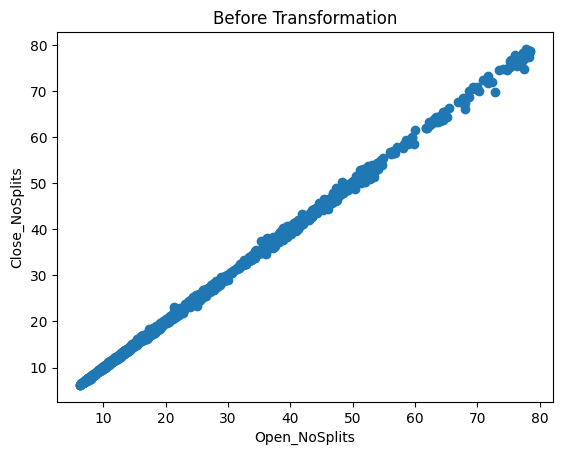

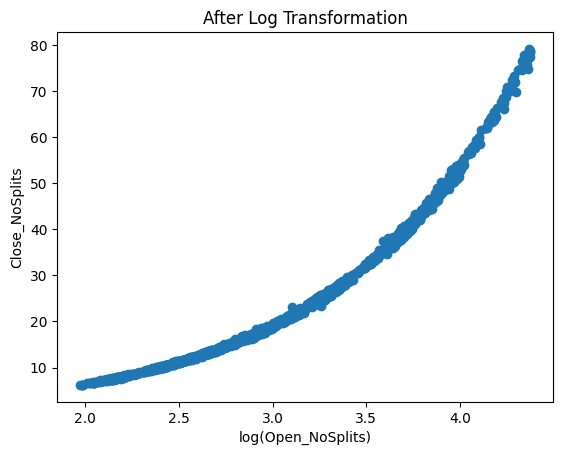

In [9]:
# Before
plt.scatter(df['Open_NoSplits'], df['Close_NoSplits'])
plt.xlabel('Open_NoSplits')
plt.ylabel('Close_NoSplits')
plt.title('Before Transformation')
plt.show()

# After
plt.scatter(df1['log_Open'], df1['Close_NoSplits'])
plt.xlabel('log(Open_NoSplits)')
plt.ylabel('Close_NoSplits')
plt.title('After Log Transformation')
plt.show()

The log transformation was not helpful and was counterproductive for showing the relationship between open and close values with no splits because the relatiosnhip started with a strong linear relationship and was transformed into a curved and nonlinear relationship. This shows that the transformation was not useful because a curved relationship is less suitable for a linear regression model.

In [10]:
#3b
df['interaction'] = df['Open_NoSplits'] * df['Prev_Close']

Justify your interaction term in 1 to 2 sentences. Why do you believe these two variables might
have a combined effect on your target? What would it mean if the interaction term improves
your model?
From our visualizations earlier we can conclude that Open_NoSplits has a strong linear relationship already. Additionaly, Prev_Close was shown to lower our RMSE score in phase 3 which combined into an interaction feature may make our prediction more accurate, if the model is improved that shows the effect of the opening price is dependent on the closing price.

In [11]:
df1['feature_binned'] = pd.cut(df1['Open_NoSplits'], bins=4, labels=False)

If you use binning, you must justify why you believe the relationship between your feature and
target is not linear. Cite your Phase 3 residual plot as evidence if applicable.

I decided to not utilize binning with Open_NoSplits because the residual plot already showed no clear pattern nor curvature with residuals scattered around 0. This indicates the relationship was already linear and a binned feature would not improve features.  

In [19]:
X_engineered = df[['Open_NoSplits', 'interaction']]
X_train_eng = X_engineered.loc[X_train.index]
X_test_eng = X_engineered.loc[X_test.index]
model_eng = LinearRegression()
model_eng.fit(X_train_eng, y_train)
y_pred_eng = model_eng.predict(X_test_eng)
rmse_eng = np.sqrt(np.mean((y_test - y_pred_eng) ** 2))
print('Engineered Model Test RMSE:', rmse_eng)
print(X_train_eng)

Engineered Model Test RMSE: 0.3093134280635376
      Open_NoSplits  interaction
1313      25.295016   639.950123
2150      11.131174   124.754355
1159      29.691481   830.951848
289       34.225167  1206.182530
1186      28.871246   820.579121
...             ...          ...
1638      15.519558   240.713145
1095      24.996709   638.416489
1130      25.151620   608.266591
1294      23.619029   564.194386
860       25.599961   663.869826

[2013 rows x 2 columns]


Text(0.5, 1.0, 'Residual Plot: Engineered Model (Test Set)')

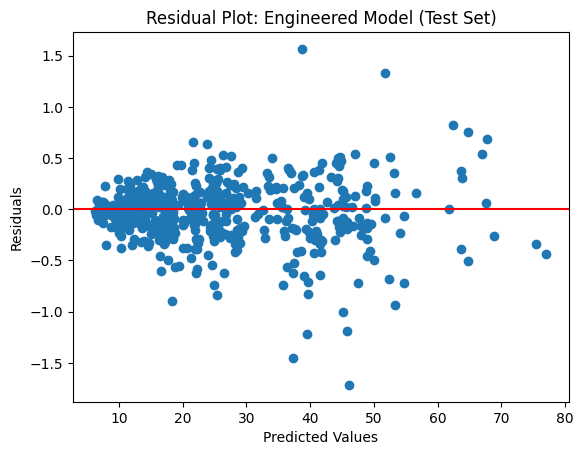

In [13]:
residuals_eng = y_test - y_pred_eng
plt.scatter(y_pred_eng, residuals_eng)
plt.axhline(0, color='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot: Engineered Model (Test Set)')

Compared to the Phase 3 Residual plot, the model shows a similar overall pattern with values centered around 0. This would mean that the model is not strongly biased. The points are mostly randomly scattered, suggesting the linear model captures the general relationship well. However, the spread of residuals inceases for higher values, indicating the model becomes less accurate at higher stock prices.

In [14]:
constant_pred = y_train.mean()

rmse_const_test = np.sqrt(np.mean((y_test - constant_pred) ** 2))

print("Constant Model Test RMSE:", rmse_const_test)

# Engineered

y_pred_train_eng = model_eng.predict(X_train_eng)

mse_eng_train = np.mean((y_train - y_pred_train_eng)**2)
rmse_eng_train = np.sqrt(mse_eng_train)

Constant Model Test RMSE: 13.989741474908026


In [15]:
table = {
        "Model": ["Constant Model", "Phase 3 SLR (Retrained)", "Engineered Feature Model"],
        "MSE (train)": [226.5060751308747,0.13758109383978998,mse_eng_train],
        "RMSE (train)": [15.050118774643432,0.37091925514832735,rmse_eng_train],
        "RMSE (test)": [13.989741474908026,0.31223951395579874,rmse_eng],
        "Improvement Over Baseline": ["N/A", "~13.68", "~13.68 (Slightly better)"]
        }

table = pd.DataFrame(table)
table

,Model,MSE (train),RMSE (train),RMSE (test),Improvement Over Baseline
0,Constant Model,226.506075,15.050119,13.989741,N/A
1,Phase 3 SLR (Retrained),0.137581,0.370919,0.312240,~13.68
2,Engineered Feature Model,0.139769,0.373856,0.309313,~13.68 (Slightly better)


6a:

The goal of the project was to determine whether the opening price of Apple Stock is able to accurately predict the closing price. This quesiton matters because being able to predict stock prices, is important for understanding market behavior. The data for our project comes from historical Apple Stock data between 2010 to 2020. The target variable was Close_NoSplits, which represents the stock's closing price. This is worth predicting bceause it reflects the final market value of the stock at the end of each trading day.

6b: During phase 2, the most important pattern we observed was the shape of the data, and the very strong correlation between Opening and Closing periods. We also noticed the slope upward the graph has. Our EDA is what ultimately led is to CHANGING our question in phase 3.

6c: In phase 3, the simple linear model was defined as: 
predicted Close_NoSplits = -0.03044 + 1.00155 × Open_NoSplits
According to the comparison table, the constant model had a test RMSE of approximately $13.99, while the linear model reduced this error to about $0.31. This shows a large improvement in our accuracy. In phase 4, feature engineering was applied by adding an interaction term between Open_NoSplits and Prev_Close. While this slightly reduced our test RMSE to 0.309, the improvement was minimal.

6d: The residual plot shows that while most residuals are centered around zero, the spread increases for higher predicted values. This indicates that the model becomes less accurate at higher prices. This pattern indicates that the model is missing information related to how stock price variability changes at different price levels.

6e: To improve the model, it would likely be good to add additional features such as trading volume or price volatility, as these may help explain the fluctuations in stock prices. Another thing, would be incorporating more time-based features, to try and help see what's going on from more than a day to day basis, and more for overarching periods. Another thing could be exploring more than just linear models.

In [18]:
df.to_csv('phase4.csv', index=False)

df

,Date,Close_Splits,Volume_Splits,Open_Splits,High_Splits,Low_Splits,Open_NoSplits,High_NoSplits,Low_NoSplits,Close_NoSplits,...,Profit,pred_constant,error,squared_error,pred_linear,error_linear,squared_error_linear,Prev_Close,log_Open,interaction
0,2020-02-27,$273.52,80151380,$281.1,$286,$272.96,67.984578,69.169651,66.015900,66.151337,...,False,26.17548,39.975856,1598.069090,67.353379,-1.202042,1.444906,66.112656,4.233883,4494.641022
1,2020-02-26,$292.65,49678430,$286.53,$297.88,$286.5,69.297844,72.042865,69.290589,70.777977,...,True,26.17548,44.602497,1989.382708,68.220993,2.556984,6.538168,66.151337,4.252741,4584.145017
2,2020-02-25,$288.08,57668360,$300.95,$302.53,$286.13,72.785347,73.167470,69.201100,69.672707,...,False,26.17548,43.497226,1892.008693,72.109833,-2.437127,5.939587,70.777977,4.301160,5151.599644
3,2020-02-24,$298.18,55548830,$297.26,$304.18,$289.23,71.892933,73.566545,69.950862,72.115433,...,True,26.17548,45.939952,2110.479227,71.142269,0.973164,0.947048,69.672707,4.288992,5008.975229
4,2020-02-21,$313.05,32426420,$318.62,$320.45,$310.5,77.058879,77.501472,75.095042,75.711761,...,False,26.17548,49.536281,2453.843149,75.357597,0.354165,0.125433,72.115433,4.357463,5557.134392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2512,2010-03-05,$31.2786,224647427,$30.7057,$31.3857,$30.6614,6.446276,6.589033,6.436978,6.566540,...,True,26.17548,-19.608941,384.510550,6.474153,0.092387,0.008535,6.570438,2.007714,42.354857
2513,2010-03-04,$30.1014,89591907,$29.8971,$30.1314,$29.8043,6.276525,6.325710,6.257030,6.319412,...,True,26.17548,-19.856069,394.263459,6.362392,-0.042981,0.001847,6.566540,1.984653,41.215052
2514,2010-03-03,$29.9043,92846488,$29.8486,$29.9814,$29.7057,6.266330,6.294222,6.236339,6.278026,...,True,26.17548,-19.897454,395.908685,6.269189,0.008837,0.000078,6.319412,1.983251,39.599520
2515,2010-03-02,$29.8357,141486282,$29.99,$30.1186,$29.6771,6.296020,6.323012,6.230339,6.263630,...,False,26.17548,-19.911850,396.481787,6.273999,-0.010369,0.000108,6.278026,1.987329,39.526577
